# Value at Risk and Conditional Value at Risk.
This notebook will demonstrate how Value at Risk (VaR) and Conditional Value at Risk (CVaR) can be calculated in this repository.

Note: To avoid fetching data from yfinance every time DataIngestion is called, as mentioned previously, save the files from DataIngestion as a a file of your choice, or cache the files in memory. This will speed up the processing of the data and allow you to quickly calculate VaR, CVaR, and other Financial Mathematical calculations in this project.

## Illustration of Returns.
Before the calculating VaR and CVaR, here is an illustration of returns as a histogram with all asset classes in this dataset.

[*********************100%***********************]  121 of 121 completed
/tmp/ipykernel_23734/323067183.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Assets", bbox_to_anchor=(1.02, 1), loc="upper left")


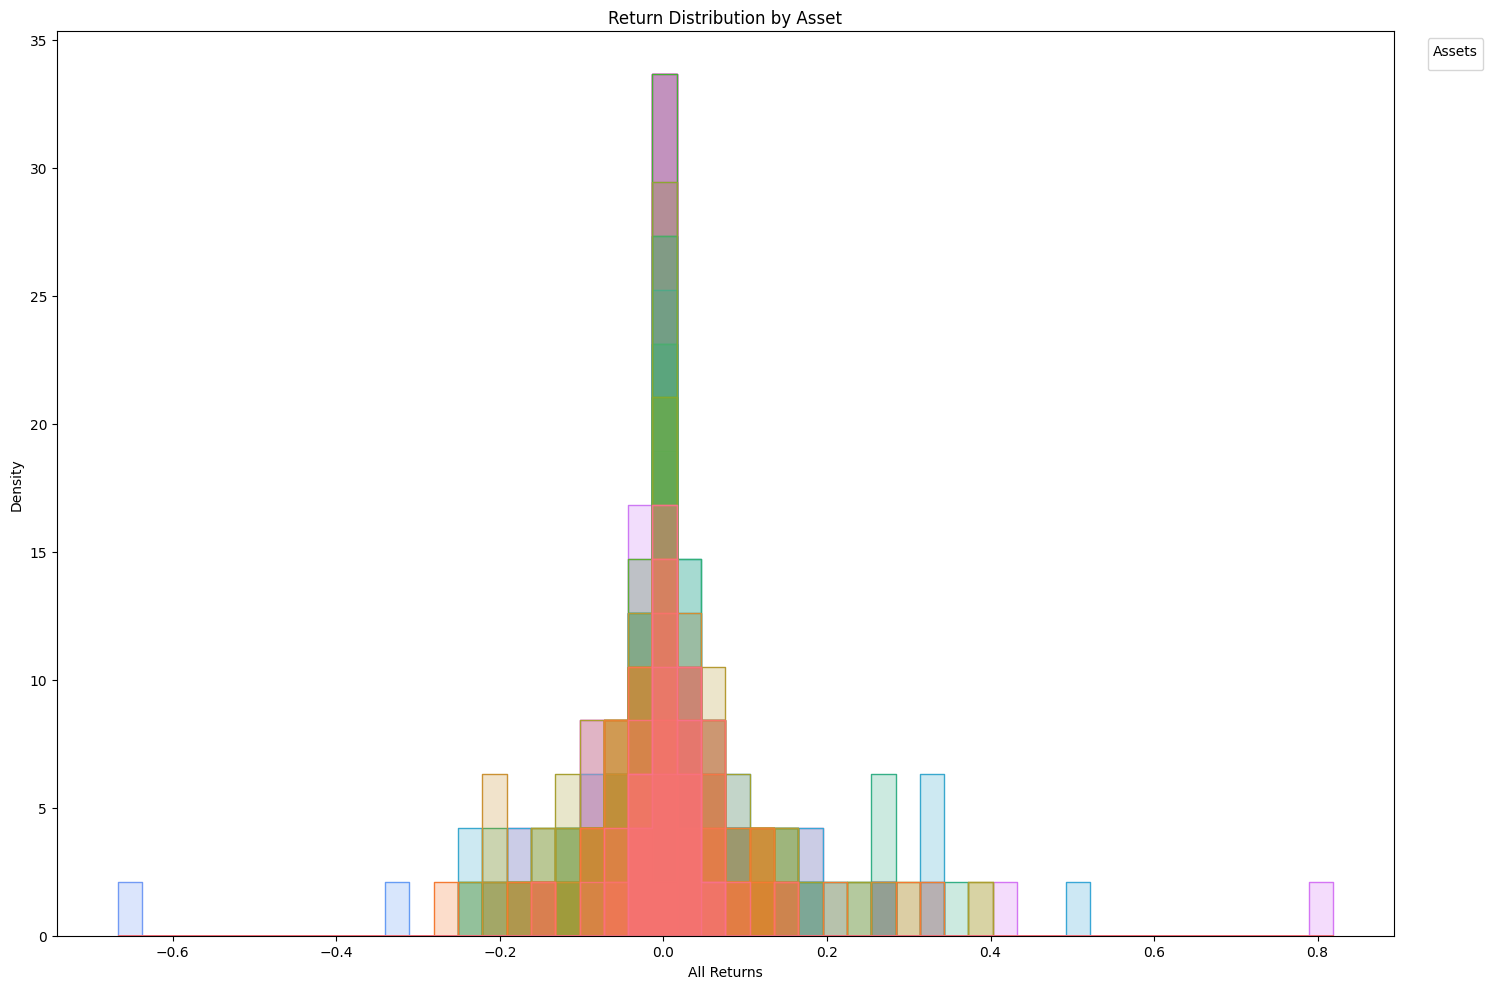

In [1]:
# data ingestion
import matplotlib.pyplot as plt
import seaborn as sns

from portfolio.data.data_ingestion import DataIngestion


obj = DataIngestion()

# all prices for all returns

all_prices = obj.get_all_prices()


# all returns using 'get_all_prices' method.

all_returns = obj.compute_returns(all_prices)


# all_returns: DataFrame with one column per asset
returns_long = all_returns.stack().reset_index()
returns_long.columns = ["Date", "Asset", "Return"]

plt.figure(figsize=(15, 10))
sns.histplot(
    data=returns_long,
    x="Return",
    hue="Asset",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.25,
)

plt.xlabel("All Returns")
plt.ylabel("Density")
plt.title("Return Distribution by Asset")
plt.legend(title="Assets", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Explanation of the output
The histogram shows the distribution of all returns in the dataset, this includes all stocks, all bonds, all etf's, all crypto currencies, and the SP500 ticker. The point of this is this is to demonstrate the distribution of a high number of assets returns. This is the Central Limit Theorem. As more samples are added to the distribution, the distribution will approach a normal distribution. This is important to understand when calculating VaR and CVaR, as these calculations assume that returns are normally distributed.

## Returns with less assets.
The next histogram will demonstrate what the distribution of returns looks like when there are less samples.

[*********************100%***********************]  4 of 4 completed


<Figure size 1500x1000 with 0 Axes>

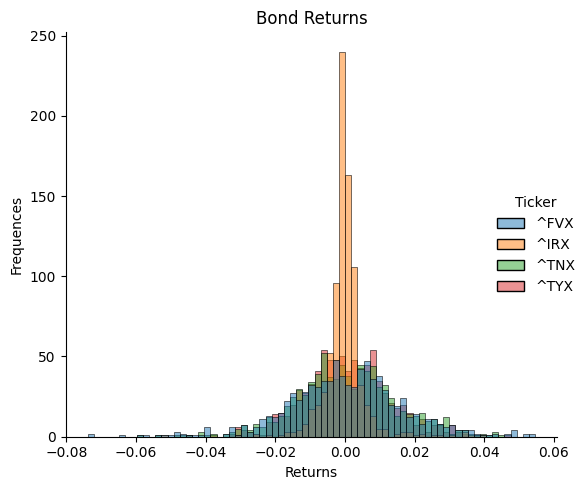

In [2]:
# returns of bonds.

bond_returns = obj.compute_returns(obj.get_bond_prices())

plt.figure(figsize=(15, 10))
sns.displot(bond_returns)
plt.title("Bond Returns")
plt.xlabel("Returns")
plt.ylabel("Frequences")
plt.tight_layout()
plt.show()

Bonds are more stable than stocks, and therefore have less volatility. This is reflected in the histogram, as the distribution of returns for bonds is more concentrated around the mean, while the distribution of returns for stocks is more spread out.

## Crypto Returns.
The next histogram will demonstrate what the distribution of returns looks like when there are only crypto assets.

[*********************100%***********************]  26 of 26 completed


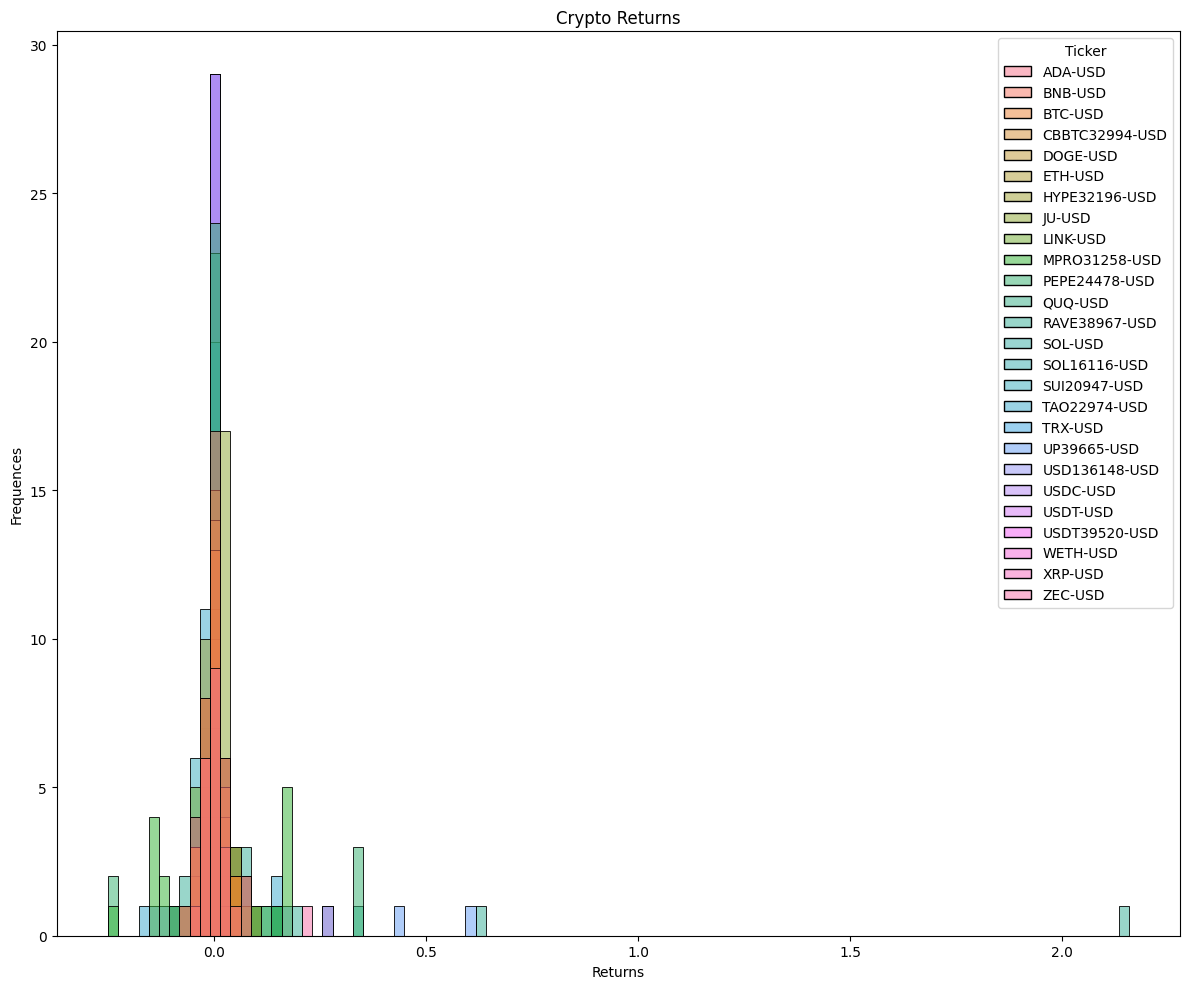

In [4]:
crypto_returns = obj.compute_returns(obj.get_crypto_prices())

plt.figure(figsize=(12, 10))
sns.histplot(crypto_returns, bins=100)
plt.title("Crypto Returns")
plt.xlabel("Returns")
plt.ylabel("Frequences")
plt.tight_layout()
plt.show()

## Value at Risk (VaR)
The Value at Risk (VaR) is a measure of the potential loss in value of a portfolio over a defined period for a given confidence interval.

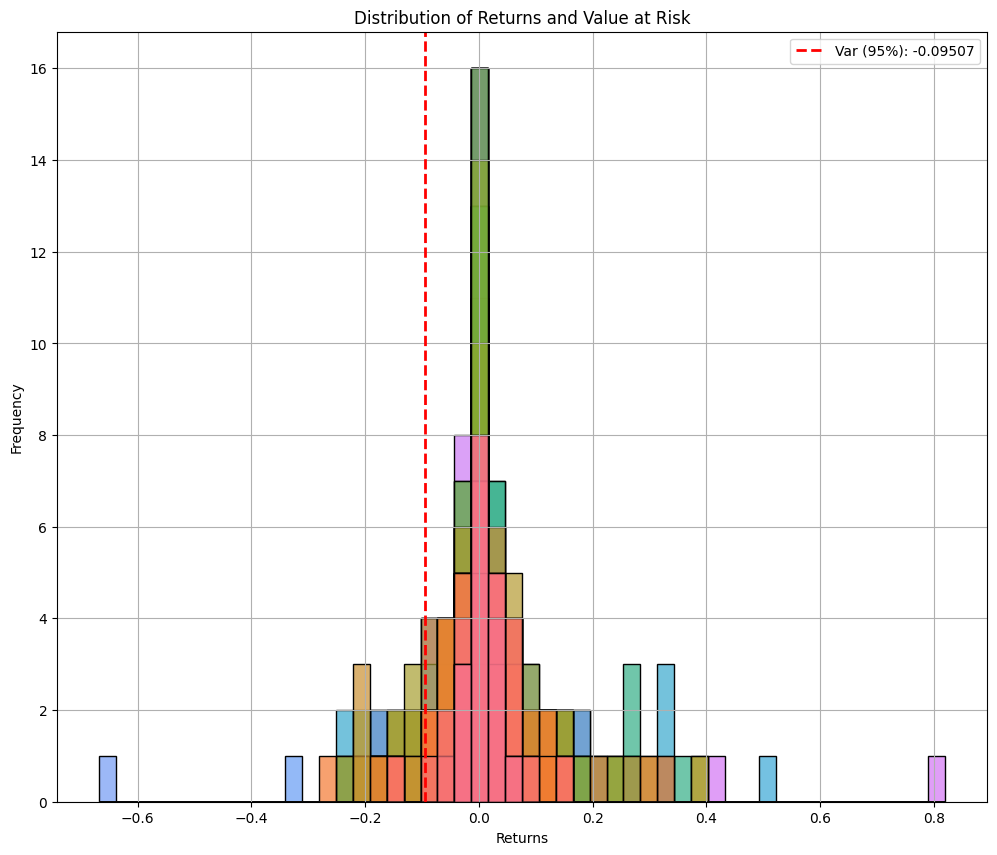

In [6]:
from portfolio.models.risk import get_var

# value at risk for all prices
var_all = get_var(all_prices)


plt.figure(figsize=(12, 10))
sns.histplot(all_returns, bins=50, alpha=0.7)
plt.axvline(var_all, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_all:.4}')
plt.title('Distribution of Returns and Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Conditional Value at Risk (CVaR)
The Conditional Value at Risk (CVaR) is a measure of the expected loss in value of a portfolio over a defined period for a given confidence interval, given that the loss exceeds the VaR. It is also known as the Expected Shortfall (ES). The Conditional Value at Risk is usually viewed as the worst case scenario of the Value at Risk. It is the expected loss given that the loss exceeds the VaR. It is a more conservative measure of risk than VaR, as it takes into account the tail risk of the distribution of returns.


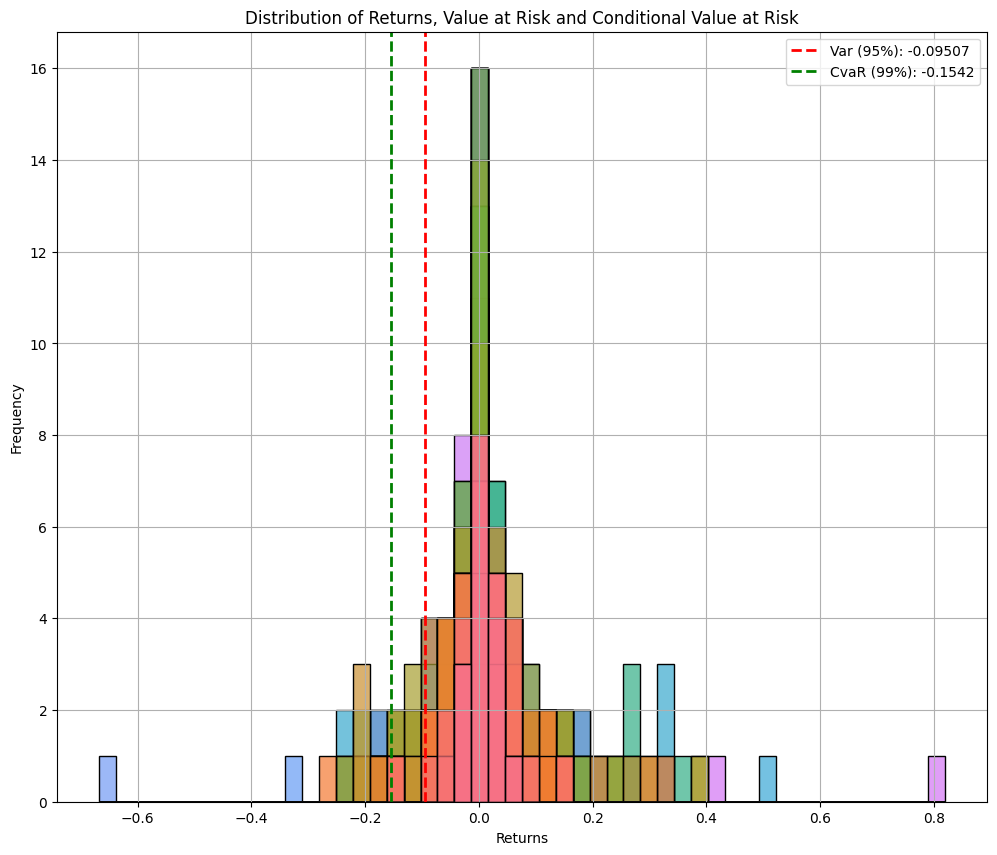

In [7]:
from portfolio.models.risk import get_cvar

cvar_all = get_cvar(all_prices)

plt.figure(figsize=(12, 10))
sns.histplot(all_returns, bins=50, alpha=0.7)
plt.axvline(var_all, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_all:.4}')
plt.axvline(cvar_all, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_all:.4}')
plt.title('Distribution of Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()





### Explanation of the output
The histogram shows both the Value at Risk and the Conditional Value at Risk as a vertical line. As is shown, the Conditional Value at Risk is further to the left than the Value at Risk.

## VaR and CVar with other asset classes.
The Value at Risk and Conditional Value at Risk can be used on other asset classes as well. Here is an example of the Value at Risk and Conditional Value at Risk for the only stock returns.

[*********************100%***********************]  54 of 54 completed


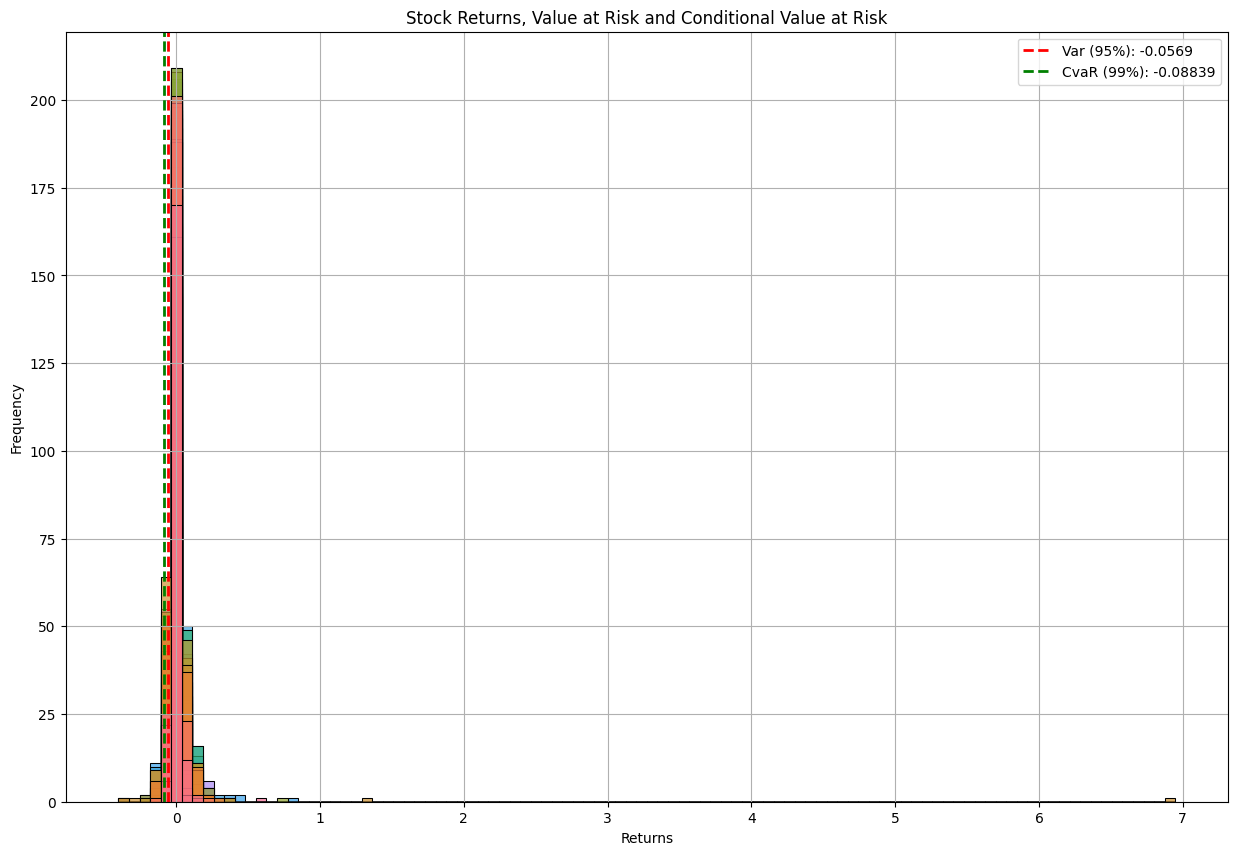

In [9]:
# load in stock prices and computer stock returns.
stock_prices = obj.get_stock_prices()
stock_returns = obj.compute_returns(stock_prices)


# Value at Risk and Conditional Value at Risk for stocks.
var_stocks = get_var(stock_prices)
cvar_stocks = get_cvar(stock_prices)




plt.figure(figsize=(15, 10))
sns.histplot(stock_returns, bins=100, alpha=0.7)
plt.axvline(var_stocks, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_stocks, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Stock Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()










[*********************100%***********************]  4 of 4 completed


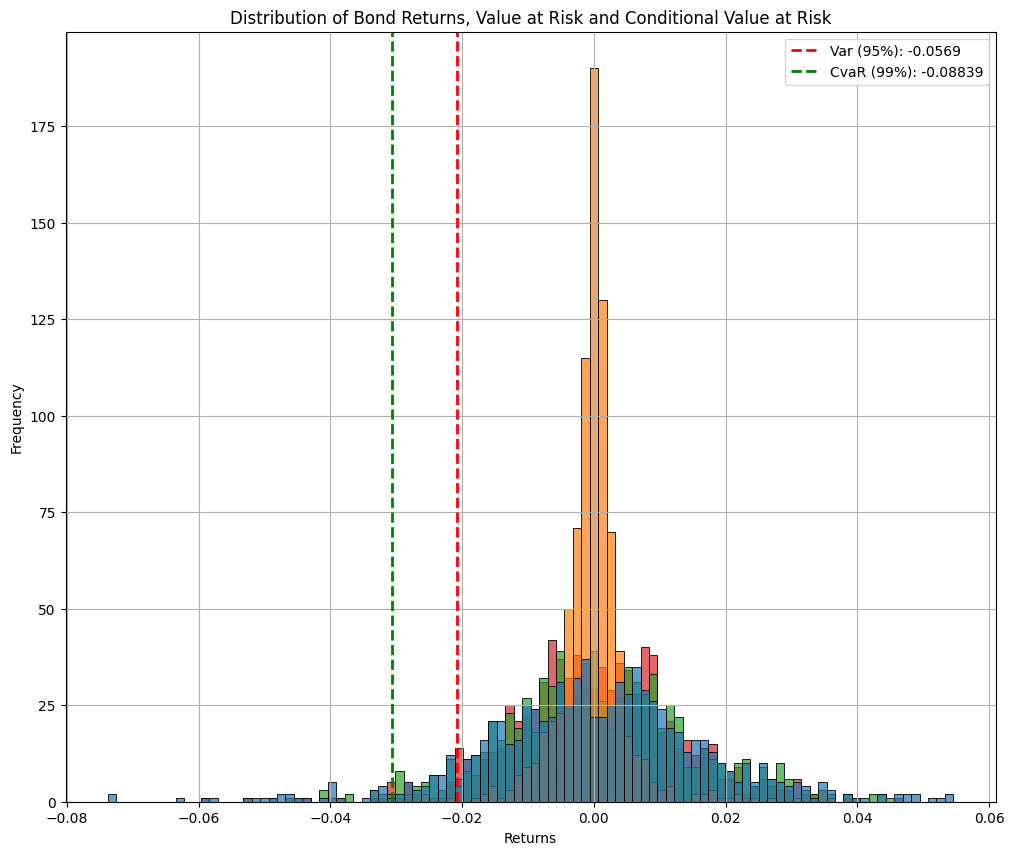

In [10]:
# bond VaR and CVaR

bond_prices = obj.get_bond_prices()
bond_returns = obj.compute_returns(bond_prices)

# VaR and CVaR for bonds.
var_bonds = get_var(bond_prices)
cvar_bonds = get_cvar(bond_prices)


plt.figure(figsize=(12, 10))
sns.histplot(bond_returns, bins=100, alpha=0.7)
plt.axvline(var_bonds, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_bonds, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Distribution of Bond Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()



[*********************100%***********************]  36 of 36 completed


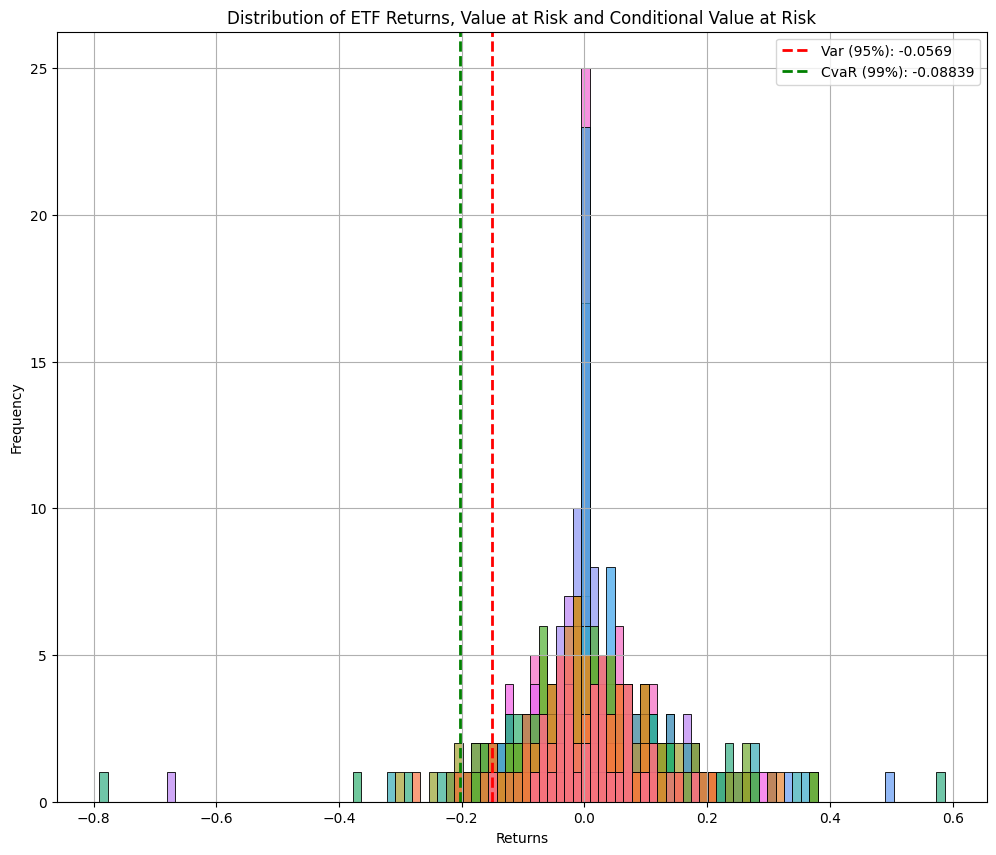

In [11]:
# Etf VaR and CVaR

etf_prices = obj.get_etf_prices()
etf_returns = obj.compute_returns(etf_prices)

var_etf = get_var(etf_prices)
cvar_etf = get_cvar(etf_prices)


plt.figure(figsize=(12, 10))
sns.histplot(etf_returns, bins=100, alpha=0.7)
plt.axvline(var_etf, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_etf, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Distribution of ETF Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

